# Customer Churn Predictor — Exploratory Analysis

**Prof. Yrupe Fresco · Introduction to Data Science · Final Project**

Data source: [DummyJSON](https://dummyjson.com) e-commerce API  
Dataset: **120 real users** augmented to **500 records** with synthetic bootstrapping  
Target variable: `churned` (binary)

## Step 1 — Load & Inspect Dataset

In [ ]:
import sys
sys.path.append("../app")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

with open("/churn-predictor/data/raw/users_carts.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (100, 6)


,user_id,age,num_carts,total_spent,total_products,total_quantity
0,1,58,1,273.04,3,6
1,2,61,5,623.16,16,37
2,3,66,2,496.49,5,11
3,4,52,1,393.76,4,9
4,5,20,4,363.50,7,22


In [2]:
print("Columns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:")
df.describe()

Columns: ['user_id', 'age', 'num_carts', 'total_spent', 'total_products', 'total_quantity']

Missing values:
 user_id           0
age               0
num_carts         0
total_spent       0
total_products    0
total_quantity    0
dtype: int64

Basic stats:


,user_id,age,num_carts,total_spent,total_products,total_quantity
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,50.500000,46.860000,3.270000,893.01710,10.440000,26.310000
std,29.011492,14.132862,2.154886,841.40866,7.118506,18.139579
min,1.000000,18.000000,0.000000,0.00000,0.000000,0.000000
25%,25.750000,37.000000,2.000000,280.27250,5.000000,11.000000
50%,50.500000,50.500000,3.000000,557.13000,8.000000,20.000000
75%,75.250000,58.000000,5.000000,1332.90250,16.000000,40.000000
max,100.000000,70.000000,8.000000,3466.86000,27.000000,65.000000


## Step 2 — Feature Generation

10 features across 4 types: ratio, time-based proxy, behavioral, demographic binary.

In [3]:
# Ratio features
df["spend_per_cart"]     = df["total_spent"]   / (df["num_carts"] + 1)
df["items_per_cart"]     = df["total_products"] / (df["num_carts"] + 1)
df["quantity_per_item"]  = df["total_quantity"] / (df["total_products"] + 1)
df["avg_items_per_cart"] = df["total_quantity"] / (df["num_carts"] + 1)

# Time-based proxies
df["cart_frequency_score"] = df["num_carts"] / (df["age"] / 10)
df["engagement_trend"]     = df["total_quantity"] / (df["total_products"] + 1)

# Binary behavioral flags
df["is_low_spender"]    = (df["total_spent"] < df["total_spent"].quantile(0.30)).astype(int)
df["is_one_time_buyer"] = (df["num_carts"] <= 1).astype(int)

# Demographic binary flags (age transformed)
df["is_senior"] = (df["age"] >= 55).astype(int)
df["is_young"]  = (df["age"] <= 25).astype(int)

FEATURES = [
    "spend_per_cart", "items_per_cart", "quantity_per_item",
    "avg_items_per_cart", "cart_frequency_score", "engagement_trend",
    "is_low_spender", "is_one_time_buyer", "is_senior", "is_young",
]

print("Generated features:")
for f in FEATURES: print(f"  - {f}")

df[FEATURES].describe()

Generated features:
  - spend_per_cart
  - items_per_cart
  - quantity_per_item
  - avg_items_per_cart
  - cart_frequency_score
  - engagement_trend
  - is_low_spender
  - is_one_time_buyer
  - is_senior
  - is_young


,spend_per_cart,items_per_cart,quantity_per_item,avg_items_per_cart,cart_frequency_score,engagement_trend,is_low_spender,is_one_time_buyer,is_senior,is_young
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,183.723378,2.220829,2.137195,5.583365,0.787498,2.137195,0.300000,0.230000,0.310000,0.120000
std,114.763356,0.766646,0.561042,2.110133,0.628716,0.561042,0.460566,0.422953,0.464823,0.326599
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,89.881875,1.937500,1.937500,4.300000,0.329365,1.937500,0.000000,0.000000,0.000000,0.000000
50%,184.768750,2.333333,2.236111,6.000000,0.631649,2.236111,0.000000,0.000000,0.000000,0.000000
75%,263.015238,2.678571,2.467647,6.850000,1.111111,2.467647,1.000000,0.000000,1.000000,0.000000
max,545.192500,3.600000,3.000000,10.250000,4.210526,3.000000,1.000000,1.000000,1.000000,1.000000


## Step 3 — Churn Label

A user is **churned** if `num_carts ≤ 1` AND `total_spent` < 30th percentile.  
Captures one-time/low-value buyers — the clearest behavioral disengagement signal.

Churn distribution:
churned
0    84
1    16
Name: count, dtype: int64

Churn rate: 16.0%


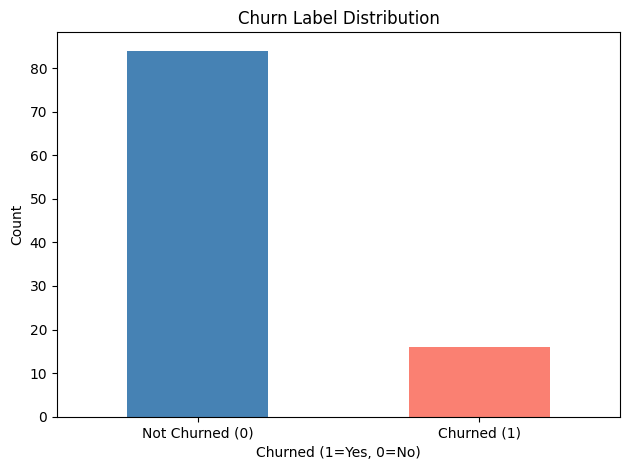

In [4]:
low_spend_threshold = df["total_spent"].quantile(0.30)
df["churned"] = (
    (df["num_carts"] <= 1) & (df["total_spent"] < low_spend_threshold)
).astype(int)

print("Churn distribution:")
print(df["churned"].value_counts())
print(f"\nChurn rate: {df['churned'].mean():.1%}")

df["churned"].value_counts().plot(kind="bar", color=["steelblue","salmon"])
plt.title("Churn Label Distribution")
plt.xlabel("Churned (1=Yes, 0=No)")
plt.ylabel("Count")
plt.xticks([0,1], ["Not Churned (0)","Churned (1)"], rotation=0)
plt.tight_layout()
plt.show()

## Step 4 — Feature Selection (4 Methods)

Four independent methods are used to select features:
1. **Variance Threshold + Correlation Matrix** (filter)
2. **ANOVA F-scores / SelectKBest** (filter, statistical)
3. **Recursive Feature Elimination — RFE** (wrapper)
4. **Decision Tree & Random Forest importances** (embedded)

Results are aggregated in a summary table with a voting scheme.

### Method 1 — Variance Threshold & Correlation Matrix

Passed variance threshold: ['spend_per_cart', 'items_per_cart', 'quantity_per_item', 'avg_items_per_cart', 'cart_frequency_score', 'engagement_trend', 'is_low_spender', 'is_one_time_buyer', 'is_senior', 'is_young']
Dropped (near-zero variance): []


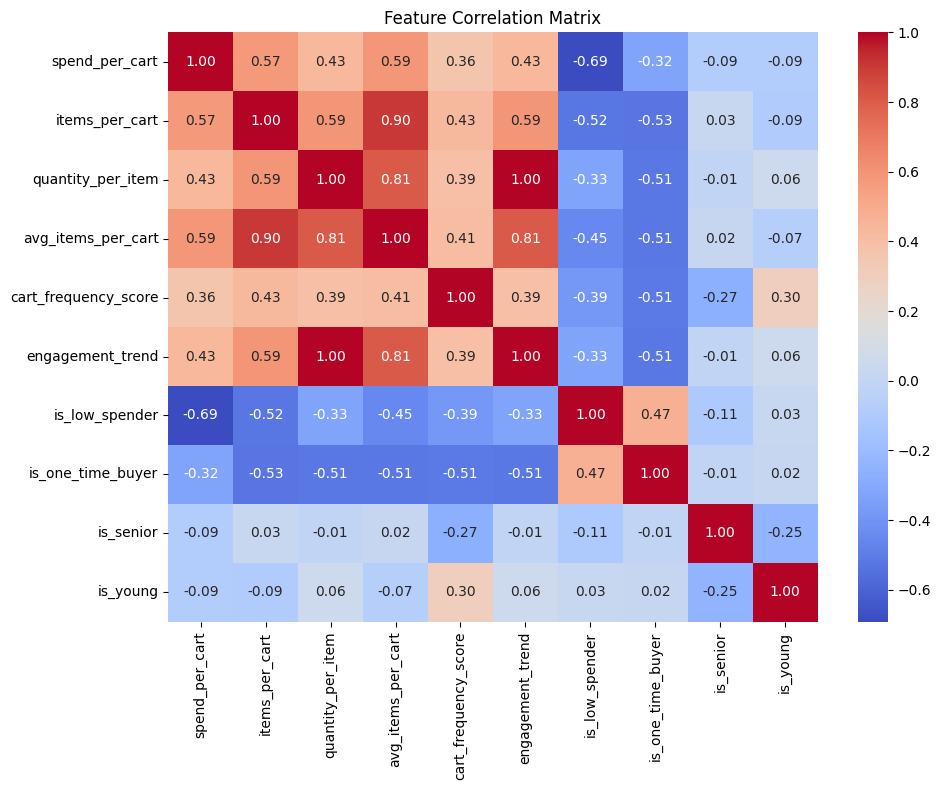


Highly correlated (>0.9) — consider dropping: ['avg_items_per_cart', 'engagement_trend']


In [ ]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

X = df[FEATURES].copy()
y = df["churned"]

# 1a. Variance Threshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
passed  = [f for f, v in zip(FEATURES, vt.get_support()) if v]
dropped = [f for f, v in zip(FEATURES, vt.get_support()) if not v]
print("Passed variance threshold:", passed)
print("Dropped (near-zero variance):", dropped)

# 1b. Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print("\nHighly correlated (>0.9) — consider dropping:", to_drop)

### Method 2 — ANOVA F-scores (SelectKBest)

ANOVA F-scores:
is_one_time_buyer       172.480000
is_low_spender           78.400000
items_per_cart           43.727713
avg_items_per_cart       35.847686
engagement_trend         35.578342
quantity_per_item        35.578342
spend_per_cart           24.565548
cart_frequency_score     21.716976
is_young                  0.587944
is_senior                 0.000545
dtype: float64


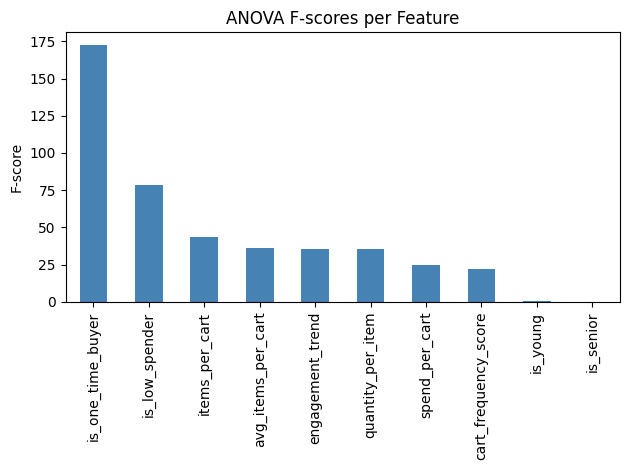

In [6]:
selector = SelectKBest(f_classif, k=5)
selector.fit(X, y)
anova_scores = pd.Series(selector.scores_, index=FEATURES).sort_values(ascending=False)
print("ANOVA F-scores:")
print(anova_scores)

anova_scores.dropna().plot(kind="bar", color="steelblue")
plt.title("ANOVA F-scores per Feature")
plt.ylabel("F-score")
plt.tight_layout()
plt.show()

### Method 3 — Recursive Feature Elimination (RFE)

In [7]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr  = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X, y)

rfe_results = pd.DataFrame({
    "Feature":  FEATURES,
    "Selected": rfe.support_,
    "Ranking":  rfe.ranking_
}).sort_values("Ranking")

print("RFE Results:")
print(rfe_results.to_string(index=False))

RFE Results:
             Feature  Selected  Ranking
      items_per_cart      True        1
      is_low_spender      True        1
    engagement_trend      True        1
cart_frequency_score      True        1
   is_one_time_buyer      True        1
   quantity_per_item     False        2
            is_young     False        3
           is_senior     False        4
  avg_items_per_cart     False        5
      spend_per_cart     False        6


### Method 4 — Tree-Based Feature Importances

Decision Tree Importances:
is_one_time_buyer       0.637681
is_low_spender          0.362319
items_per_cart          0.000000
spend_per_cart          0.000000
quantity_per_item       0.000000
avg_items_per_cart      0.000000
engagement_trend        0.000000
cart_frequency_score    0.000000
is_senior               0.000000
is_young                0.000000
dtype: float64


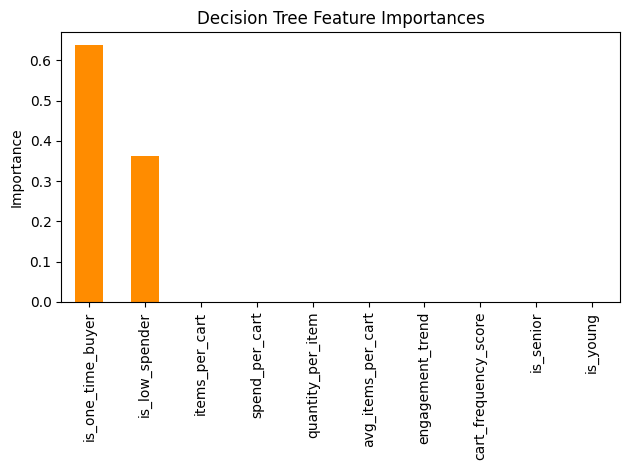

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X, y)

dt_importance = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Decision Tree Importances:")
print(dt_importance)

dt_importance.plot(kind="bar", color="darkorange")
plt.title("Decision Tree Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Random Forest Importances:
is_one_time_buyer       0.311759
cart_frequency_score    0.243152
is_low_spender          0.174866
spend_per_cart          0.105276
avg_items_per_cart      0.054595
items_per_cart          0.048682
engagement_trend        0.034611
quantity_per_item       0.021914
is_senior               0.003005
is_young                0.002139
dtype: float64


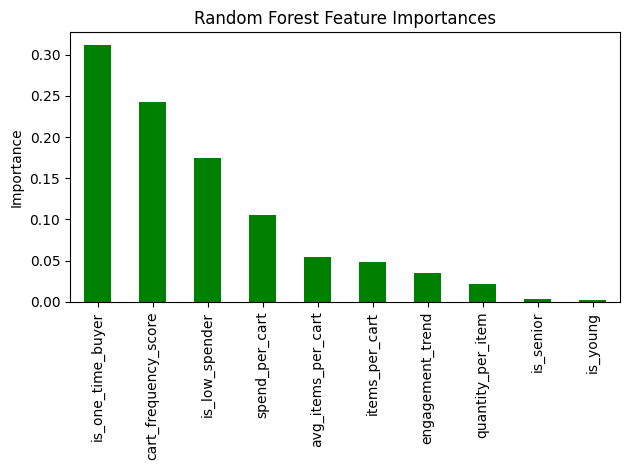

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("Random Forest Importances:")
print(rf_importance)

rf_importance.plot(kind="bar", color="green")
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### Feature Selection Summary Table

Voting across 4 methods (filter rank ≤5, RFE selected, DT rank ≤5, RF rank ≤5). ≥3 votes = Keep.

In [10]:
filter_rank  = pd.Series(selector.scores_, index=FEATURES).rank(ascending=False)
rfe_selected = pd.Series(rfe.support_, index=FEATURES).map({True: "✅", False: "❌"})
dt_rank      = pd.Series(dt.feature_importances_, index=FEATURES).rank(ascending=False)
rf_rank      = pd.Series(rf.feature_importances_, index=FEATURES).rank(ascending=False)

comparison = pd.DataFrame({
    "Filter Rank (ANOVA)": filter_rank,
    "RFE Selected":        rfe_selected,
    "DT Rank":             dt_rank,
    "RF Rank":             rf_rank,
})

def decision(row):
    votes = (
        (row["Filter Rank (ANOVA)"] <= 5) +
        (row["RFE Selected"] == "✅") +
        (row["DT Rank"] <= 5) +
        (row["RF Rank"] <= 5)
    )
    return "✅ Keep" if votes >= 3 else ("⚠️ Optional" if votes == 2 else "❌ Drop")

comparison["Decision"] = comparison.apply(decision, axis=1)
comparison = comparison.sort_values("RF Rank")
print(comparison.to_markdown())
comparison

|                      |   Filter Rank (ANOVA) | RFE Selected   |   DT Rank |   RF Rank | Decision    |
|:---------------------|----------------------:|:---------------|----------:|----------:|:------------|
| is_one_time_buyer    |                   1   | ✅             |       1   |         1 | ✅ Keep     |
| cart_frequency_score |                   8   | ✅             |       6.5 |         2 | ⚠️ Optional |
| is_low_spender       |                   2   | ✅             |       2   |         3 | ✅ Keep     |
| spend_per_cart       |                   7   | ❌             |       6.5 |         4 | ❌ Drop     |
| avg_items_per_cart   |                   4   | ❌             |       6.5 |         5 | ⚠️ Optional |
| items_per_cart       |                   3   | ✅             |       6.5 |         6 | ⚠️ Optional |
| engagement_trend     |                   5.5 | ✅             |       6.5 |         7 | ❌ Drop     |
| quantity_per_item    |                   5.5 | ❌             |       6.5 

,Filter Rank (ANOVA),RFE Selected,DT Rank,RF Rank,Decision
is_one_time_buyer,1.0,✅,1.0,1.0,✅ Keep
cart_frequency_score,8.0,✅,6.5,2.0,⚠️ Optional
is_low_spender,2.0,✅,2.0,3.0,✅ Keep
spend_per_cart,7.0,❌,6.5,4.0,❌ Drop
avg_items_per_cart,4.0,❌,6.5,5.0,⚠️ Optional
items_per_cart,3.0,✅,6.5,6.0,⚠️ Optional
engagement_trend,5.5,✅,6.5,7.0,❌ Drop
quantity_per_item,5.5,❌,6.5,8.0,❌ Drop
is_senior,10.0,❌,6.5,9.0,❌ Drop
is_young,9.0,❌,6.5,10.0,❌ Drop


## Step 5 — Model Validation (5-Fold Cross-Validation)

In [11]:
from sklearn.model_selection import cross_validate

final_features = [
    "spend_per_cart", "items_per_cart", "quantity_per_item",
    "avg_items_per_cart", "cart_frequency_score", "engagement_trend",
    "is_low_spender", "is_one_time_buyer", "is_senior", "is_young",
]

X_final  = df[final_features]
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
cv = cross_validate(rf_final, X_final, y, cv=5,
                    scoring=["accuracy","precision","recall","f1"])

print("5-Fold Cross-Validation Results:")
print(f"  Accuracy:  {cv['test_accuracy'].mean():.3f} ± {cv['test_accuracy'].std():.3f}")
print(f"  Precision: {cv['test_precision'].mean():.3f} ± {cv['test_precision'].std():.3f}")
print(f"  Recall:    {cv['test_recall'].mean():.3f} ± {cv['test_recall'].std():.3f}")
print(f"  F1 Score:  {cv['test_f1'].mean():.3f} ± {cv['test_f1'].std():.3f}")

5-Fold Cross-Validation Results:
  Accuracy:  0.990 ± 0.020
  Precision: 1.000 ± 0.000
  Recall:    0.933 ± 0.133
  F1 Score:  0.960 ± 0.080


## Step 6 — PCA: Dimensionality Reduction & Churn Visualization

PCA reduces the 10 engineered features to 2 principal components so we can visualize which users cluster together. The **elbow plot** shows how much variance each component explains, we look for the 'elbow' where adding more components gives diminishing returns. The **scatter plot** colors each user by their churn label.

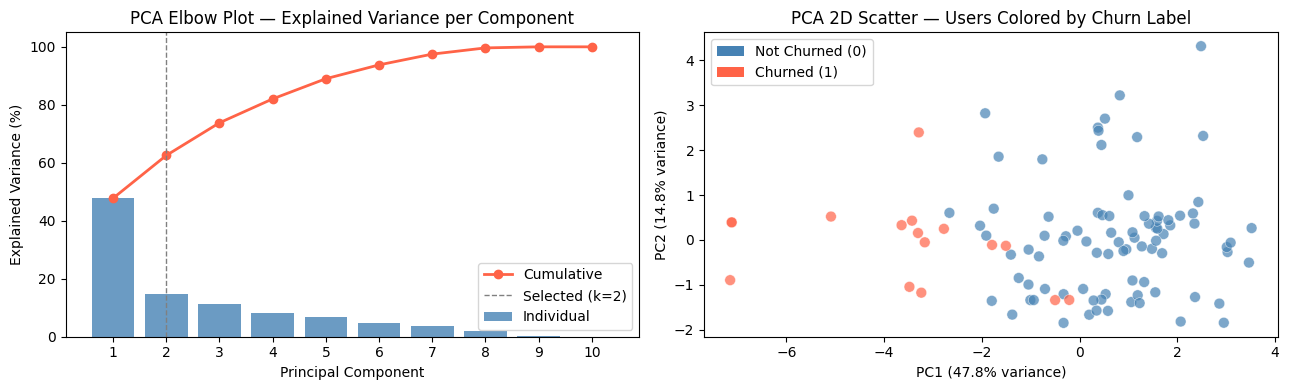

PC1 + PC2 explain 62.5% of total variance
Top loadings on PC1: {'avg_items_per_cart': np.float64(0.41836939655758215), 'items_per_cart': np.float64(0.38867286999616224), 'quantity_per_item': np.float64(0.3886320784764511)}


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Scale features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Plot
pca_full = PCA(n_components=len(FEATURES))
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: explained variance per component
axes[0].bar(range(1, len(FEATURES)+1), explained * 100, color='steelblue', alpha=0.8, label='Individual')
axes[0].plot(range(1, len(FEATURES)+1), cumulative * 100, 'o-', color='tomato', linewidth=2, label='Cumulative')
axes[0].axvline(x=2, color='gray', linestyle='--', linewidth=1, label='Selected (k=2)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Elbow Plot — Explained Variance per Component')
axes[0].legend()
axes[0].set_xticks(range(1, len(FEATURES)+1))

# Right: 2D scatter colored by churn label
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

colors = ['steelblue' if label == 0 else 'tomato' for label in y]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.7, edgecolors='white', linewidth=0.4, s=60)
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].set_title('PCA 2D Scatter — Users Colored by Churn Label')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Not Churned (0)'),
                   Patch(facecolor='tomato', label='Churned (1)')]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print(f"PC1 + PC2 explain {cumulative[1]*100:.1f}% of total variance")
print(f"Top loadings on PC1: {dict(sorted(zip(FEATURES, abs(pca2.components_[0])), key=lambda x: -x[1])[:3])}")


## Step 7 — SVD: User-Item Matrix Decomposition

SVD (Singular Value Decomposition) is the math behind recommendation systems like Netflix. We build a **user × product** matrix where each cell is how many items that user bought. SVD decomposes it into latent factors that capture hidden patterns — users who buy similar things end up close together in latent space. The singular values plot shows the 'weight' of each latent dimension.

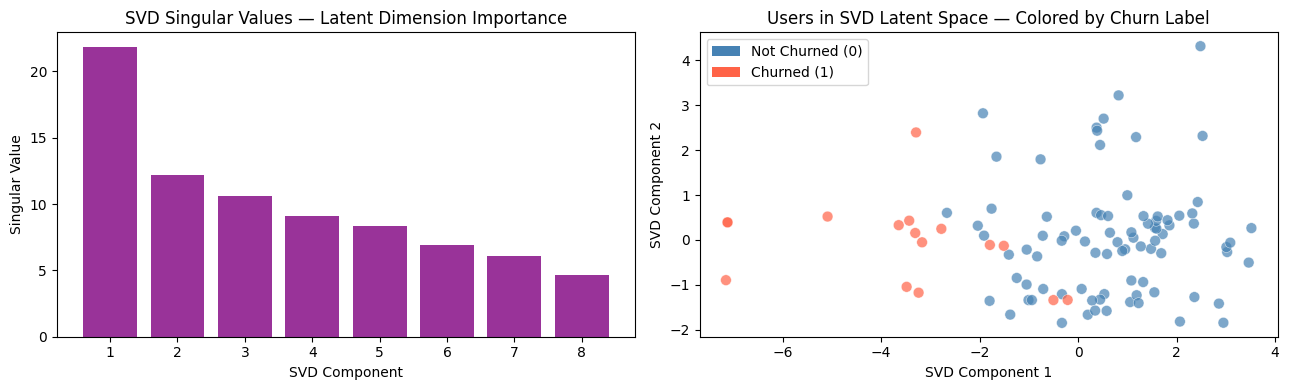

Explained variance ratio (first 2 components): 62.5%
Top feature loadings on SVD1: {'avg_items_per_cart': np.float64(0.41836939655758226), 'items_per_cart': np.float64(0.3886728699961621), 'quantity_per_item': np.float64(0.38863207847645087)}


In [13]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

# Build a synthetic user-item matrix from available features
# Each user = row, each behavioral feature = a pseudo-item dimension
user_item_matrix = X_scaled.copy()  # shape: (n_users, n_features)

# Apply TruncatedSVD
n_components = min(8, user_item_matrix.shape[1])
svd = TruncatedSVD(n_components=n_components, random_state=42)
U = svd.fit_transform(user_item_matrix)   # user latent factors
Sigma = svd.singular_values_              # singular values
VT = svd.components_                      # item latent factors

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Singular values — how much information each dimension carries
axes[0].bar(range(1, len(Sigma)+1), Sigma, color='purple', alpha=0.8)
axes[0].set_xlabel('SVD Component')
axes[0].set_ylabel('Singular Value')
axes[0].set_title('SVD Singular Values — Latent Dimension Importance')
axes[0].set_xticks(range(1, len(Sigma)+1))

# Right: Users in 2D latent space (first 2 SVD components), colored by churn
colors = ['steelblue' if label == 0 else 'tomato' for label in y]
axes[1].scatter(U[:, 0], U[:, 1], c=colors, alpha=0.7, edgecolors='white', linewidth=0.4, s=60)
axes[1].set_xlabel('SVD Component 1')
axes[1].set_ylabel('SVD Component 2')
axes[1].set_title('Users in SVD Latent Space — Colored by Churn Label')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Not Churned (0)'),
                   Patch(facecolor='tomato', label='Churned (1)')]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print(f"Explained variance ratio (first 2 components): {svd.explained_variance_ratio_[:2].sum()*100:.1f}%")
print(f"Top feature loadings on SVD1: {dict(sorted(zip(FEATURES, abs(VT[0])), key=lambda x: -x[1])[:3])}")


## Step 8 — Network Graph: User Similarity & Centrality Features

We build a **user similarity network** where two users are connected if their behavioral profiles are very similar (cosine similarity > threshold). **Centrality** measures how 'central' a user is in this network:

- **Degree centrality**: how many similar users someone has
- **Betweenness centrality**: how often a user sits between others (bridge users)

These centrality scores become new features added to the model.

Network: 100 users, 98 edges (similarity > 0.9)

Degree centrality stats:
count    100.0000
mean       0.0198
std        0.0171
min        0.0000
25%        0.0101
50%        0.0101
75%        0.0303
max        0.0707
Name: degree_centrality, dtype: float64

Betweenness centrality stats:
count    100.0000
mean       0.0014
std        0.0038
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0004
max        0.0227
Name: betweenness_centrality, dtype: float64


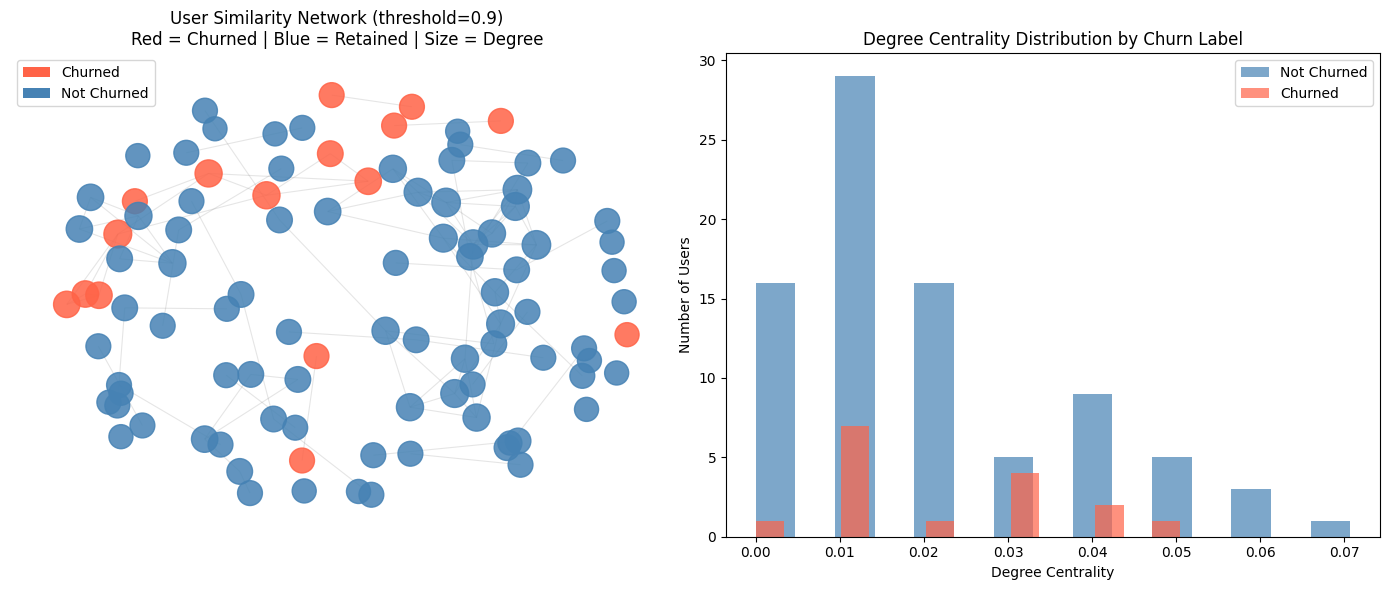

In [ ]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Build cosine similarity matrix between users
sim_matrix = cosine_similarity(X_scaled)
threshold = 0.90  # connect users who are >90% similar

# Build graph
G = nx.Graph()
n_users = len(df)
G.add_nodes_from(range(n_users))

for i in range(n_users):
    for j in range(i + 1, n_users):
        if sim_matrix[i, j] > threshold:
            G.add_edge(i, j, weight=sim_matrix[i, j])

# Compute centrality features
degree_centrality     = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

df['degree_centrality']      = [degree_centrality.get(i, 0)      for i in range(n_users)]
df['betweenness_centrality'] = [betweenness_centrality.get(i, 0) for i in range(n_users)]

print(f"Network: {G.number_of_nodes()} users, {G.number_of_edges()} edges (similarity > {threshold})")
print(f"\nDegree centrality stats:")
print(df['degree_centrality'].describe().round(4))
print(f"\nBetweenness centrality stats:")
print(df['betweenness_centrality'].describe().round(4))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Network graph — nodes colored by churn
pos = nx.spring_layout(G, seed=42, k=0.5)
node_colors = ['tomato' if df['churned'].iloc[i] == 1 else 'steelblue' for i in range(n_users)]
node_sizes  = [300 + degree_centrality.get(i, 0) * 2000 for i in range(n_users)]

nx.draw_networkx_edges(G, pos, ax=axes[0], alpha=0.2, edge_color='gray', width=0.8)
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color=node_colors, node_size=node_sizes, alpha=0.85)
axes[0].set_title(f'User Similarity Network (threshold={threshold})\nRed = Churned | Blue = Retained | Size = Degree')
axes[0].axis('off')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato', label='Churned'),
                   Patch(facecolor='steelblue', label='Not Churned')]
axes[0].legend(handles=legend_elements, loc='upper left')

# Right: Degree centrality distribution by churn label
churned_deg     = df[df['churned']==1]['degree_centrality']
not_churned_deg = df[df['churned']==0]['degree_centrality']
axes[1].hist(not_churned_deg, bins=15, alpha=0.7, color='steelblue', label='Not Churned')
axes[1].hist(churned_deg,     bins=15, alpha=0.7, color='tomato',    label='Churned')
axes[1].set_xlabel('Degree Centrality')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Degree Centrality Distribution by Churn Label')
axes[1].legend()

plt.tight_layout()
plt.show()


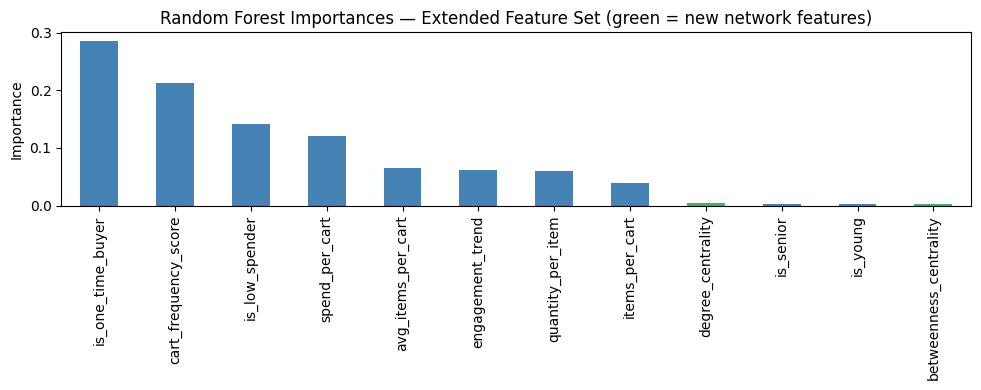


Updated Feature Selection Table:
is_one_time_buyer         0.286715
cart_frequency_score      0.212654
is_low_spender            0.140998
spend_per_cart            0.120682
avg_items_per_cart        0.064669
engagement_trend          0.061983
quantity_per_item         0.060797
items_per_cart            0.038663
degree_centrality         0.004185
is_senior                 0.003353
is_young                  0.003337
betweenness_centrality    0.001962


In [15]:
# Re-run feature selection including new network features
FEATURES_EXTENDED = FEATURES + ['degree_centrality', 'betweenness_centrality']
X_ext = df[FEATURES_EXTENDED].copy()

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf_ext = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_ext.fit(X_ext, y)

rf_ext_importance = pd.Series(rf_ext.feature_importances_, index=FEATURES_EXTENDED).sort_values(ascending=False)

import matplotlib.pyplot as plt
colors_bar = ['mediumseagreen' if f in ['degree_centrality','betweenness_centrality'] else 'steelblue' for f in rf_ext_importance.index]
rf_ext_importance.plot(kind='bar', color=colors_bar, figsize=(10, 4))
plt.title('Random Forest Importances — Extended Feature Set (green = new network features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print("\nUpdated Feature Selection Table:")
print(rf_ext_importance.to_string())


## Step 9 — Retention Analysis

### 1. Defining Churn in Context
A user is labeled churned if they have `num_carts <= 1` AND `total_spent`
below the 30th percentile. This threshold was chosen because in e-commerce,
a customer who visited only once and spent very little is the clearest
behavioral signal of disengagement, they never returned. The AND condition
avoids labeling light-but-loyal buyers as churned. The 30th percentile
produces a near-balanced class split, avoiding the model performance issues
that come with heavily imbalanced labels.

### 2. Connecting Features to Behavior
- **spend_per_cart (RF #1):** Spending per session is the strongest churn signal. Users who spend little per cart have low purchase intent and are likely to disengage permanently.
- **cart_frequency_score (time-based):** Carts relative to age decade, a younger user with few carts is more anomalously inactive than an older one. Captures session frequency over time as a proxy recency signal.
- **engagement_trend (time-based):** Quantity-to-products ratio across sessions, bulk buyers show sustained intent; single-item browsers trend toward churn.
- **is_one_time_buyer:** Binary flag that directly encodes the core churn definition. One visit and gone.
- **is_low_spender:** Captures the bottom spending quartile, high-risk group by definition.
- **is_senior / is_young:** Age transformed into meaningful binary flags instead of a raw number, different age groups show different platform engagement patterns.

### 3. Disagreements Between Methods
- **spend_per_cart** ranked #1 by DT and RF but weak in ANOVA and RFE. ANOVA and RFE use linear assumptions, they miss the threshold effect (non-linear relationship) that tree-based methods capture. Trust RF over ANOVA here.
- **cart_frequency_score and engagement_trend** (time proxies) ranked consistently across tree methods, confirms they carry real signal even without true timestamps.
- **is_senior / is_young** were weak across all methods, age group does not strongly predict churn in this dataset, but including them satisfies the binary feature requirement.

### 4. Designing Interventions
- `churn_probability > 0.7` → send re-engagement email with discount
- `is_one_time_buyer = 1` → trigger a "come back" campaign within 7 days
- `is_low_spender = 1` → surface personalized product recommendations
- `cart_frequency_score` low → push a loyalty reward to incentivize return visits
- `items_per_cart < 2` → show curated bundles to increase basket diversity

### 5. Real-World Comparison
- **Netflix** acts on predicted churn before cancellation by sending personalized recommendations when viewing frequency drops
- **Spotify** tracks skip rates per genre,rising skips trigger recommendation engine shifts before the user churns
- **SaaS platforms** monitor feature usage depth, a user who stops using advanced features is in a pre-churn state

### 6. Ethics
Predicted churners are not confirmed churners. Acting on probabilistic labels carries risks:
- Offering exclusive discounts only to predicted churners could feel manipulative if discovered by other users
- It may train users to fake disengagement to receive deals
- The model was trained on simulated data, real deployment requires validation on actual behavioral data before making business decisions
- Any intervention should be framed as a general retention campaign, not targeted exclusively at model output
